# Lecture 9 — Direct Method I: Single Shooting with dymos

This notebook introduces [dymos](https://openmdao.github.io/dymos/), an optimal
control library built on [OpenMDAO](https://openmdao.org/), and uses it to walk
through the **single shooting** transcription of optimal control problems.

**Roadmap**

1. **The brachistochrone**, transcribed by single shooting and solved with dymos
2. **Under the hood** — the NLP the optimizer actually sees: design variables,
   constraints, and the total Jacobian (considerably denser for shooting than
   for collocation — a preview of Lecture 10)
3. **Minimum time** — the double integrator: bang-bang optimal control and
   the limits of fixed control grids
4. **Interactive study** — how the control discretization (number of segments,
   polynomial order) affects the solution

## Recap: single shooting as an NLP

The continuous optimal control problem

$$
\min_{u(\cdot),\,t_f} \; J = \phi\big(x(t_f), t_f\big)
\qquad \text{s.t.} \quad \dot{x} = f(x, u, t), \quad x(t_0) = x_0, \quad
\psi\big(x(t_f)\big) = 0, \quad u \in \mathcal{U}
$$

is *transcribed* into a finite-dimensional nonlinear program (NLP) by:

1. **Choosing a basis for the control**: $u(t) \approx u(t;\, q)$ with a finite
   parameter vector $q$ (dymos uses piecewise Lagrange polynomials on a segmented grid).
2. **Eliminating the state by forward integration**: given $z = (t_f, q)$, a
   time integrator produces $x(t_f;\, z)$.
3. **Handing the optimizer** the NLP

$$
\min_{z} \; \phi\big(x(t_f; z), t_f\big) \qquad \text{s.t.} \quad
\psi\big(x(t_f; z)\big) = 0, \quad z_L \le z \le z_U .
$$

The states never appear as optimization variables — they are "hidden" inside
the integrator. Every evaluation of the constraints requires a full trajectory
propagation, and every evaluation of the constraint *Jacobian* requires
propagating sensitivities (the state-transition matrix) along the trajectory.

In [1]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Silence some noisy (harmless) OpenMDAO warnings before importing it
warnings.filterwarnings('ignore', message='.*INF_BOUND.*')

import openmdao
import openmdao.api as om
from openmdao.utils.om_warnings import OpenMDAOWarning, DerivativesWarning

warnings.filterwarnings('ignore', category=OpenMDAOWarning)
warnings.filterwarnings('ignore', category=DerivativesWarning)

import dymos as dm
import ipywidgets as widgets
from IPython.display import HTML, display

from oclectures import (apply_style, describe_nlp, total_jacobian,
                        plot_jacobian, quiet, redirect_outputs_to_tmp, COLORS)

apply_style()
redirect_outputs_to_tmp()  # keep OpenMDAO's problemN_out/ folders out of this directory
print(f'dymos {dm.__version__}, OpenMDAO {openmdao.__version__}')

dymos 1.15.1, OpenMDAO 3.45.1


---
## 1. The brachistochrone

A bead slides without friction along a wire from $(x_0, y_0) = (0, 10)$ m to
$(x_f, y_f) = (10, 5)$ m under gravity, starting at rest. Find the wire shape
that minimizes the transit time.

With $\theta$ the angle of the velocity vector measured from vertical (the
control), the dynamics are

$$
\dot{x} = v \sin\theta, \qquad
\dot{y} = -v \cos\theta, \qquad
\dot{v} = g \cos\theta .
$$

The analytic optimum is a **cycloid**, so we can verify everything dymos does.
(The target is defined once, as `XF, YF` at the top of the problem-building
cell below — edit it and re-run this section to solve, and verify, a
different instance live. Any target below the start height works.)

<img src="figures/brachistochrone_schematic.png" width="680"/>

Steering the velocity direction $\theta(t)$ is equivalent to choosing the wire
shape — with $\theta$ measured from the downward vertical, the dynamics above
follow directly from resolving the velocity into components
($\dot{x} = v\sin\theta$, $\dot{y} = -v\cos\theta$) and projecting gravity
onto the velocity direction ($\dot{v} = g\cos\theta$).

### The ODE as an OpenMDAO component

dymos asks us to supply the dynamics $f(x, u, t)$ as an OpenMDAO component.
A component is a block with declared **inputs** and **outputs**: here the
inputs are the quantities the dynamics depend on (the state $v$ and the
control $\theta$ — $x$ and $y$ don't appear on the right-hand side, so they
are not inputs), and the outputs are the state rates
$(\dot{x}, \dot{y}, \dot{v})$. dymos wires this block into the transcription:
it feeds trial state/control values in, collects the rates, and hands them to
the integrator.

Two things to notice:

- **Vectorization**: the component is evaluated at `num_nodes` time points at
  once — inputs and outputs are arrays, not scalars.
- **Analytic partials**: we declare and provide $\partial f / \partial (x, u)$,
  obtained by simply differentiating the dynamics by hand:

$$
\frac{\partial \dot{x}}{\partial v} = \sin\theta, \quad
\frac{\partial \dot{x}}{\partial \theta} = v\cos\theta, \quad
\frac{\partial \dot{y}}{\partial v} = -\cos\theta, \quad
\frac{\partial \dot{y}}{\partial \theta} = v\sin\theta, \quad
\frac{\partial \dot{v}}{\partial \theta} = -g\sin\theta .
$$

  The rate at node $i$ depends only on the inputs at node $i$, so these
  partials are diagonal matrices (declared with `rows=cols=arange(nn)`).
  OpenMDAO chains these component partials through the integrator to build
  exact trajectory sensitivities — no finite differencing of the integration
  ever happens.

In [2]:
class BrachistochroneODE(om.ExplicitComponent):
    """Dynamics of a bead on a frictionless wire."""

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('theta', val=np.zeros(nn), units='rad')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('ydot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')

        ar = np.arange(nn)
        self.declare_partials('xdot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('ydot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('vdot', 'theta', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        g = 9.80665
        v, theta = inputs['v'], inputs['theta']
        outputs['xdot'] = v * np.sin(theta)
        outputs['ydot'] = -v * np.cos(theta)
        outputs['vdot'] = g * np.cos(theta)

    def compute_partials(self, inputs, J):
        g = 9.80665
        v, theta = inputs['v'], inputs['theta']
        J['xdot', 'v'] = np.sin(theta)
        J['xdot', 'theta'] = v * np.cos(theta)
        J['ydot', 'v'] = -np.cos(theta)
        J['ydot', 'theta'] = v * np.sin(theta)
        J['vdot', 'theta'] = -g * np.sin(theta)

### Building the dymos problem

**Division of labor:** [OpenMDAO](https://openmdao.org/) is a general
framework for building models from components with analytic derivatives and
optimizing them — it owns the `Problem`, the data connections between
components, the drivers (optimizers), and the machinery that assembles *total*
derivatives from the component *partials*. [dymos](https://openmdao.github.io/dymos/)
sits on top and contributes the optimal-control vocabulary: `Phase`,
time/states/controls, transcriptions, boundary and path constraints,
timeseries outputs. A dymos phase is, in the end, just a large OpenMDAO model
that dymos assembles for you.

The key object is the **transcription** — it decides how the continuous
problem becomes an NLP. For single shooting we use `dm.ExplicitShooting`:

- The **grid** (`GaussLobattoGrid(num_segments, nodes_per_seg)`) defines the
  piecewise-polynomial basis for the *control only*. We use `nodes_per_seg=2`,
  the lowest order dymos offers: $\theta(t)$ is **piecewise linear**,
  continuous across segment boundaries.
- The states are obtained by **adaptive explicit integration** (DOP853 by
  default) across the whole phase — this is the "forward shooting".
- Because the final state is an *output* of integration rather than a design
  variable, terminal conditions must be posed as **boundary constraints**
  (`add_boundary_constraint`), not as `fix_final=True`.

In [3]:
XF, YF = 10.0, 5.0  # target point B -- change these and re-run the section for a live demo


def build_brachistochrone(num_segments=8, nodes_per_seg=2):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)

    grid = dm.GaussLobattoGrid(num_segments=num_segments, nodes_per_seg=nodes_per_seg)
    phase = dm.Phase(ode_class=BrachistochroneODE,
                     transcription=dm.ExplicitShooting(grid=grid))
    p.model.add_subsystem('phase0', phase)

    # Free final time: the phase duration is a design variable of the NLP.
    phase.set_time_options(fix_initial=True, duration_bounds=(0.5, 10.0), units='s')

    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    phase.add_state('y', fix_initial=True, rate_source='ydot', units='m')
    phase.add_state('v', fix_initial=True, rate_source='vdot', units='m/s')

    # Value continuity ties the duplicated control nodes at the segment
    # boundaries. Rate continuity stays OFF: matching the slopes of adjacent
    # *linear* segments as well would weld all of them into a single straight
    # line, leaving the control only two degrees of freedom.
    phase.add_control('theta', units='rad', lower=0.01, upper=3.0,
                      continuity=True, rate_continuity=False)

    # Terminal conditions as constraints on the integrated final state
    phase.add_boundary_constraint('x', loc='final', equals=XF)
    phase.add_boundary_constraint('y', loc='final', equals=YF)

    phase.add_objective('time', loc='final')

    p.setup()

    # Initial guess: duration 2 s, theta ramping linearly 0.1 -> 0.8 rad
    # (set_*_val interpolates linearly between the values given). Under
    # shooting, the state "guesses" only set the initial condition (0, 10, 0);
    # the rest of the guess trajectory is whatever integrating that control
    # produces.
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, XF])
    phase.set_state_val('y', [10, YF])
    phase.set_state_val('v', [0, 10])
    phase.set_control_val('theta', [0.1, 0.8])
    return p


p_shoot = build_brachistochrone()
t0 = time.perf_counter()
# p.run_driver() runs the optimizer directly. (dymos also offers
# dm.run_problem(p), which adds solution recording to an sqlite file and
# optional grid refinement; we skip it to keep the folder free of databases.)
p_shoot.run_driver()
wall_shooting = time.perf_counter() - t0
print(f'\nshooting solve wall time: {wall_shooting:.1f} s')

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.8016063818289196
            Iterations: 25
            Function evaluations: 26
            Gradient evaluations: 25
Optimization Complete
-----------------------------------

shooting solve wall time: 6.3 s


### Comparison with the analytic cycloid

The cycloid through both endpoints satisfies
$x = a(\varphi - \sin\varphi)$, $y = y_0 - a(1 - \cos\varphi)$, with
$\theta = \varphi / 2$ and $t = \varphi \sqrt{a / g}$.

Alongside the converged solution we also plot the **initial guess
trajectory**: a fresh copy of the problem with `run_model()` instead of the
driver performs *one forward integration of the guess control, no
optimization* — exactly what the optimizer evaluated at iteration 0. Note how
far its endpoint misses the target: under shooting, the guess only has to be
integrable, not feasible.

The circles on the control plot mark the nodal values of $\theta$ on the
transcription grid — 8 segments $\times$ 2 nodes $= 16$ values — precisely
the design variables of the NLP; between them the control is linear
interpolation. (Each interior segment boundary carries *two* coincident
nodes, one from each neighboring segment; continuity constraints, below, tie
each pair together.) The states carry no such grid under shooting: they are
continuous outputs of the integration.

Note a special feature of this problem: since $\theta = \varphi/2$ and
$\varphi$ grows at the constant rate $\sqrt{g/a}$, the optimal steering angle
is **exactly linear in time** — the velocity direction rotates at constant
speed along a cycloid. Our piecewise-linear basis therefore *contains the
exact optimum*. The optimizer doesn't know this: it adjusts the nodal values
of $\theta$, which simply converge onto a straight line. This is special to
the brachistochrone — the double integrator below has a *discontinuous*
optimal control.

final time: dymos 1.801606 s   vs  analytic 1.801603 s   (error 3.26e-06 s)


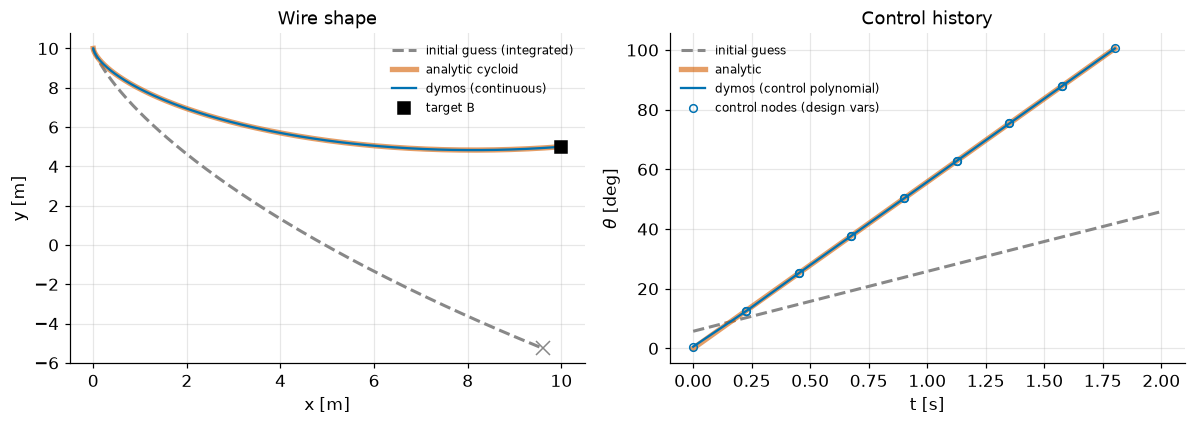

In [4]:
def brachistochrone_analytic(x0=0.0, y0=10.0, xf=XF, yf=YF, g=9.80665, n=200):
    def endpoint_eqs(unknowns):
        a, phi_f = unknowns
        return [a * (phi_f - np.sin(phi_f)) - (xf - x0),
                a * (1 - np.cos(phi_f)) - (y0 - yf)]

    a, phi_f = fsolve(endpoint_eqs, x0=[3.0, 2.0])
    phi = np.linspace(0, phi_f, n)
    return {'x': x0 + a * (phi - np.sin(phi)),
            'y': y0 - a * (1 - np.cos(phi)),
            't': phi * np.sqrt(a / g),
            'theta': phi / 2,
            'tf': phi_f * np.sqrt(a / g)}


ana = brachistochrone_analytic()

# Iteration-0 view: integrate the initial-guess control once, no optimizer
p_guess = build_brachistochrone()
p_guess.run_model()
with quiet():  # suppress dymos's setup/simulation chatter
    sim_guess = p_guess.model.phase0.simulate(times_per_seg=30)
guess = {key: sim_guess.get_val(f'phase0.timeseries.{key}')[:, 0]
         for key in ('time', 'x', 'y', 'theta')}

# The converged control values at the 16 transcription grid points ...
ts = p_shoot.get_val('phase0.timeseries.time')[:, 0]
th = p_shoot.get_val('phase0.timeseries.theta')[:, 0]

# ... and densely sampled: the states are continuous (integrated), and the
# control is a piecewise polynomial -- re-integrate with dense output to plot
# them as the continuous curves they are.
with quiet():
    sim = p_shoot.model.phase0.simulate(times_per_seg=30)
dense = {key: sim.get_val(f'phase0.timeseries.{key}')[:, 0]
         for key in ('time', 'x', 'y', 'theta')}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(guess['x'], guess['y'], '--', color=COLORS['gray'],
         label='initial guess (integrated)')
ax1.plot(guess['x'][-1], guess['y'][-1], 'x', ms=9, color=COLORS['gray'])
ax1.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.6,
         label='analytic cycloid')
ax1.plot(dense['x'], dense['y'], color=COLORS['dymos'], lw=1.5,
         label='dymos (continuous)')
ax1.plot(XF, YF, 's', ms=8, color='k', label='target B')
ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]'); ax1.set_title('Wire shape')
ax1.legend(fontsize=8)

ax2.plot(guess['time'], np.degrees(guess['theta']), '--', color=COLORS['gray'],
         label='initial guess')
ax2.plot(ana['t'], np.degrees(ana['theta']), color=COLORS['analytic'], lw=3.5,
         alpha=0.6, label='analytic')
ax2.plot(dense['time'], np.degrees(dense['theta']), color=COLORS['dymos'],
         lw=1.5, label='dymos (control polynomial)')
ax2.plot(ts, np.degrees(th), 'o', ms=5, mfc='none', color=COLORS['dymos'],
         label='control nodes (design vars)')
ax2.set_xlabel('t [s]'); ax2.set_ylabel(r'$\theta$ [deg]'); ax2.set_title('Control history')
ax2.legend(fontsize=8)
fig.tight_layout()

print(f"final time: dymos {ts[-1]:.6f} s   vs  analytic {ana['tf']:.6f} s   "
      f"(error {abs(ts[-1] - ana['tf']):.2e} s)")

### Watching the optimizer work

To see *how* SLSQP got there, we re-solve while recording every driver
evaluation (OpenMDAO's `SqliteRecorder` attached to the driver), then animate
the recorded iterates. Note a defining feature of shooting: **every frame is a
dynamically feasible trajectory** — the integrator guarantees the dynamics —
it just ends in the wrong place until the boundary constraints are converged.
(The frames are driver *evaluations*, which include line-search trials, so
there are a few more of them than SLSQP's reported iteration count.)

In [5]:
from pathlib import Path

rec_file = Path.cwd() / 'driver_iters.db'  # absolute path: no *_out folder
p_rec = build_brachistochrone()
p_rec.driver.add_recorder(om.SqliteRecorder(rec_file))
p_rec.driver.recording_options['includes'] = ['phase0.timeseries.*']
with quiet():
    p_rec.run_driver()
p_rec.cleanup()  # close the recorder's database file

frames = [{key: case[f'phase0.timeseries.{key}'][:, 0]
           for key in ('time', 'x', 'y', 'theta')}
          for case in om.CaseReader(rec_file).get_cases('driver')]
rec_file.unlink()  # frames are in memory; nothing left on disk
print(f'{len(frames)} recorded driver evaluations')

27 recorded driver evaluations


In [6]:
from matplotlib import animation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Static backdrop: initial guess, analytic optimum, target
ax1.plot(guess['x'], guess['y'], '--', color=COLORS['gray'], label='initial guess')
ax1.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.6,
         label='analytic cycloid')
ax1.plot(XF, YF, 's', ms=8, color='k', label='target B')
line_xy, = ax1.plot([], [], color=COLORS['dymos'], lw=1.8, label='current evaluation')
info = ax1.text(0.03, 0.03, '', transform=ax1.transAxes, fontsize=9)
all_x = np.concatenate([f['x'] for f in frames])
all_y = np.concatenate([f['y'] for f in frames])
ax1.set_xlim(min(all_x.min(), 0) - 0.5, max(all_x.max(), XF) + 0.8)
ax1.set_ylim(min(all_y.min(), YF - 0.5) - 0.5, 11)
ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]')
ax1.set_title('Integrated trajectory'); ax1.legend(fontsize=8, loc='upper right')

ax2.plot(guess['time'], np.degrees(guess['theta']), '--', color=COLORS['gray'])
ax2.plot(ana['t'], np.degrees(ana['theta']), color=COLORS['analytic'], lw=3.5, alpha=0.6)
line_th, = ax2.plot([], [], 'o-', ms=4, mfc='none', lw=1.2, color=COLORS['dymos'])
th_max = max(np.degrees(f['theta']).max() for f in frames)
t_max = max(f['time'][-1] for f in frames)
ax2.set_xlim(0, t_max + 0.1); ax2.set_ylim(-5, max(th_max, 100) + 10)
ax2.set_xlabel('t [s]'); ax2.set_ylabel(r'$\theta$ [deg]')
ax2.set_title('Control nodes')


def update(k):
    f = frames[k]
    line_xy.set_data(f['x'], f['y'])
    line_th.set_data(f['time'], np.degrees(f['theta']))
    miss = np.hypot(f['x'][-1] - XF, f['y'][-1] - YF)
    info.set_text(f"evaluation {k}/{len(frames) - 1}:   "
                  f"$t_f$ = {f['time'][-1]:.3f} s,   endpoint miss = {miss:.2f} m")
    return line_xy, line_th, info


ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=300, blit=True)
plt.close(fig)  # display only the animation player below, not a static copy
HTML(ani.to_jshtml(default_mode='once'))

---
## 2. Under the hood: the NLP the optimizer sees

What exactly did dymos hand to SLSQP? Let's list the design variables and
constraints. Note what is **absent**: the states $x, y, v$ are *not* design
variables — only the duration $t_f$ and the control nodal values are.
(That changes completely under collocation, below.)

In [7]:
describe_nlp(p_shoot, title='Brachistochrone, single shooting');

=== Brachistochrone, single shooting ===

Design variables (z):
  t_duration                                 size    1
  theta                                      size   16

Constraints (c(z)):
  x[final]                                   size    1
  y[final]                                   size    1
  cont.: theta                               size    7

Objective (f(z)):
  t

--> NLP with 17 variables and 9 constraints


### The total Jacobian

At every optimizer iteration, SLSQP needs

$$
\nabla_z c(z) = \frac{\partial \psi}{\partial x(t_f)} \,
\underbrace{\frac{\partial x(t_f)}{\partial z}}_{\text{via STM propagation}}
$$

Each **column** of this Jacobian is the sensitivity of the final state to one
control parameter — obtained by propagating derivatives *through the entire
integration*. A control node early in the trajectory influences everything
downstream, so every row that involves the integrated state — here the two
boundary constraints — is **fully coupled**: no zero entries, no structure for
the optimizer to exploit. Refining the grid only makes such rows longer, never
sparser, and each one gains a column's worth of STM propagation; the cost of a
Jacobian evaluation grows with both trajectory length and the number of
control parameters.

Rows = the objective plus **all 9 constraints** from the table above. One
subtlety: the 7 control-*value* continuity constraints are declared **linear**
by dymos — their rows are constant ($\pm 1$ entries pairing the duplicated
nodal values at each segment boundary), so the optimizer computes them once
and never again; a plain `compute_totals()` would omit them entirely. Our
helper requests them explicitly so the picture matches the full NLP — you can
spot them as the constant banded block, clearly different in character from
the two fully coupled boundary-constraint rows, which must be re-propagated
at every iteration.

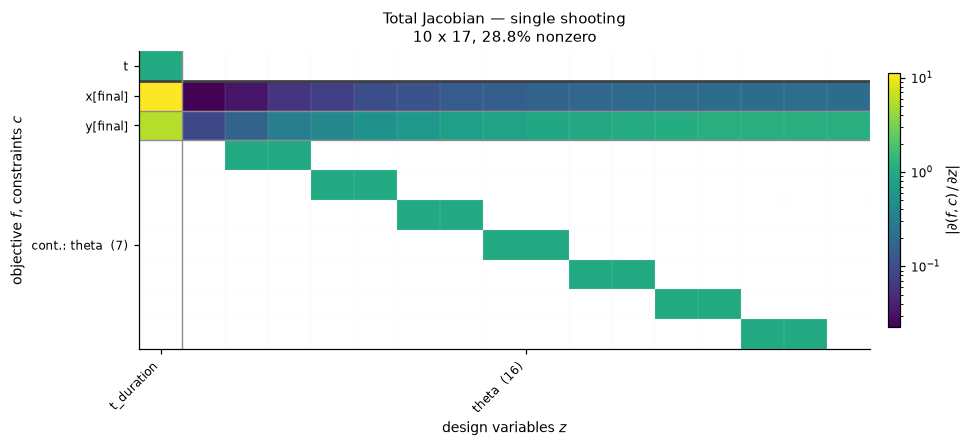

In [8]:
J_shoot, of_b, wrt_b = total_jacobian(p_shoot)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
plot_jacobian(J_shoot, of_b, wrt_b, ax=ax,
              title='Total Jacobian — single shooting')
fig.tight_layout()

### A preview of Lecture 10

Are fully coupled Jacobian rows bad? Only compared to the alternative. Next
lecture introduces **collocation** transcriptions, which restructure the NLP
completely. We won't explain the recipe here — just run the same
brachistochrone through one (Gauss–Lobatto collocation) and compare what the
optimizer sees. Two differences are visible even without the theory: the
states can now be fixed at *both* ends (`fix_final=True`), and no boundary
constraints are needed.

In [9]:
def build_brachistochrone_collocation(num_segments=10, order=3):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)

    phase = dm.Phase(ode_class=BrachistochroneODE,
                     transcription=dm.GaussLobatto(num_segments=num_segments, order=order))
    p.model.add_subsystem('phase0', phase)

    phase.set_time_options(fix_initial=True, duration_bounds=(0.5, 10.0), units='s')
    phase.add_state('x', fix_initial=True, fix_final=True, rate_source='xdot', units='m')
    phase.add_state('y', fix_initial=True, fix_final=True, rate_source='ydot', units='m')
    phase.add_state('v', fix_initial=True, fix_final=False, rate_source='vdot', units='m/s')
    phase.add_control('theta', units='rad', lower=0.01, upper=3.0,
                      continuity=True, rate_continuity=True)
    phase.add_objective('time', loc='final')

    p.setup()
    phase.set_time_val(initial=0.0, duration=2.0)
    # With fix_final=True the endpoint of the state guess doubles as the
    # imposed terminal value, so the target enters through XF, YF here.
    phase.set_state_val('x', [0, XF])
    phase.set_state_val('y', [10, YF])
    phase.set_state_val('v', [0, 10])
    phase.set_control_val('theta', [0.1, 0.8])
    return p


p_colloc = build_brachistochrone_collocation()
t0 = time.perf_counter()
p_colloc.run_driver()
wall_colloc = time.perf_counter() - t0
tf_colloc = p_colloc.get_val('phase0.timeseries.time')[-1, 0]
print(f'\ncollocation solve wall time: {wall_colloc:.1f} s '
      f'(vs {wall_shooting:.1f} s shooting), tf = {tf_colloc:.6f} s')

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.8016058455467583
            Iterations: 52
            Function evaluations: 53
            Gradient evaluations: 52
Optimization Complete
-----------------------------------

collocation solve wall time: 0.4 s (vs 6.3 s shooting), tf = 1.801606 s


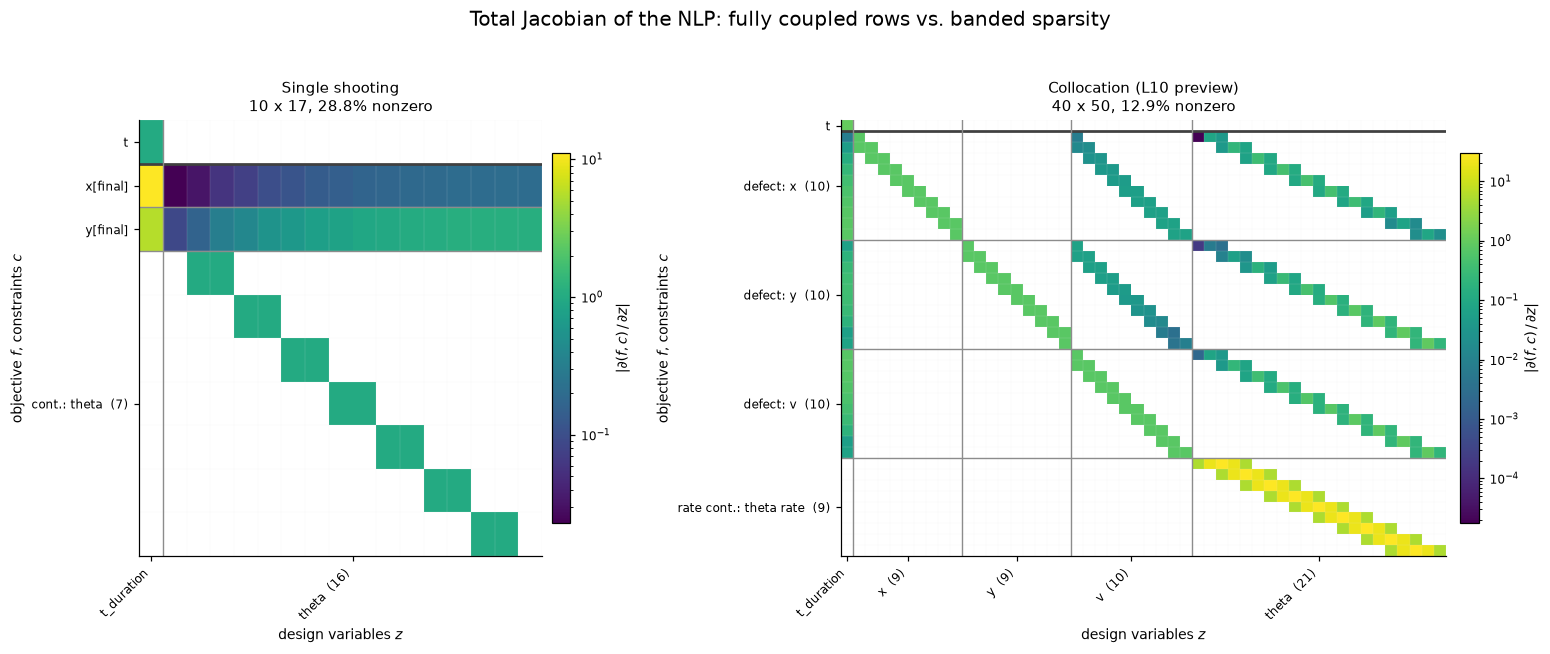

In [10]:
J_colloc, of_c, wrt_c = total_jacobian(p_colloc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.8),
                               gridspec_kw={'width_ratios': [1, 1.5]})
plot_jacobian(J_shoot, of_b, wrt_b, ax=ax1, title='Single shooting')
plot_jacobian(J_colloc, of_c, wrt_c, ax=ax2, title='Collocation (L10 preview)')
fig.suptitle('Total Jacobian of the NLP: fully coupled rows vs. banded sparsity', y=1.02)
fig.tight_layout()

**The cliffhanger for Lecture 10:** collocation solved the identical
problem an order of magnitude faster, and its NLP — though roughly three
times the size — is mostly empty, with every constraint touching only a
handful of neighboring variables. Where did the states come from as
variables? What are those "defect" constraint blocks? Why does sparsity buy
so much? That is the subject of the next lecture. (Meanwhile, the
sensitivity propagation that makes shooting expensive is exactly the
state-transition-matrix machinery we will meet again in the indirect method,
Lecture 11.)

*(Optional: run `om.n2(p_shoot)` to open OpenMDAO's interactive N2 model
diagram and explore how dymos wires the ODE into the integrator.)*

---
## 3. Minimum time and bang-bang control: the double integrator

Minimum-time transfer of a double integrator ($\ddot{x} = u$), starting with
an initial velocity:

$$
\min t_f \quad \text{s.t.} \quad \dot{x} = v, \quad \dot{v} = u, \quad
|u| \le 1,
$$

from $x(0) = 0,\; v(0) = v_0 = 0.5$ to $x(t_f) = 1,\; v(t_f) = 0$.

The analytic optimum is **bang-bang**: accelerate at $u = +1$, then brake at
$u = -1$. Matching position and velocity at the switch gives

$$
t_s = \sqrt{d + v_0^2/2} - v_0, \qquad t_f = 2\sqrt{d + v_0^2/2} - v_0,
$$

so for $v_0 = 0.5$, $d = 1$: $t_s \approx 0.561$ s and $t_f \approx 1.621$ s.
The nonzero $v_0$ is deliberate: it places the switch at $t_s/t_f \approx 35\%$
of the phase — *not* at the midpoint, and nowhere a uniform grid is likely to
put a segment boundary. (With $v_0 = 0$ the problem is symmetric and the
switch sits exactly at $t_f/2$ — can you see why that would make some segment
counts accidentally perfect?)

As before, the final time is free: the phase duration is a design variable.
Segment boundaries are fixed *fractions* of the duration, so all segments
stretch and shrink together as the optimizer varies $t_f$ — a fact that will
matter shortly.

**Choosing the control basis.** Since the optimal control is piecewise
constant, a high-order polynomial basis is the wrong tool. We keep the
piecewise-linear basis of the brachistochrone (`nodes_per_seg=2`), but now set
`continuity=False`, which lets the control **jump at segment boundaries**. A
saturated linear segment is constant in practice, so this basis can represent
the exact bang-bang solution *provided a segment boundary falls on the switch
time*. That proviso is the whole story of this section — a weakness of any
fixed-grid transcription. The next notebook fixes it head-on by making the
boundary a design variable (the two-phase formulation of multiple shooting);
collocation with mesh refinement (L10) and the indirect method (L11) will
address it in their own ways.

In [11]:
class DoubleIntegratorODE(om.ExplicitComponent):

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('u', val=np.zeros(nn), units='m/s**2')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')

        ar = np.arange(nn)
        self.declare_partials('xdot', 'v', rows=ar, cols=ar, val=1.0)
        self.declare_partials('vdot', 'u', rows=ar, cols=ar, val=1.0)

    def compute(self, inputs, outputs):
        outputs['xdot'] = inputs['v']
        outputs['vdot'] = inputs['u']

In [12]:
V0, D = 0.5, 1.0  # initial velocity, transfer distance


def build_double_integrator(num_segments=5, nodes_per_seg=2, continuity=False):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=400, tol=1e-9)
    p.driver.options['disp'] = False  # we print our own one-line summaries

    grid = dm.GaussLobattoGrid(num_segments=num_segments, nodes_per_seg=nodes_per_seg)
    phase = dm.Phase(ode_class=DoubleIntegratorODE,
                     transcription=dm.ExplicitShooting(grid=grid))
    p.model.add_subsystem('phase0', phase)

    phase.set_time_options(fix_initial=True, duration_bounds=(0.3, 10.0), units='s')
    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m')
    phase.add_state('v', fix_initial=True, rate_source='vdot', units='m/s')

    # Default basis: piecewise linear (nodes_per_seg=2) with jumps allowed at
    # segment boundaries (continuity=False) -- the natural choice for a
    # control we know is piecewise constant.
    phase.add_control('u', units='m/s**2', lower=-1.0, upper=1.0,
                      continuity=continuity, rate_continuity=False)

    phase.add_boundary_constraint('x', loc='final', equals=D)
    phase.add_boundary_constraint('v', loc='final', equals=0.0)
    phase.add_objective('time', loc='final')

    p.setup()
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, D])
    phase.set_state_val('v', [V0, 0])
    phase.set_control_val('u', [1.0, -1.0])
    return p


def analytic_double_integrator(v0=V0, d=D, n=400):
    ts = np.sqrt(d + v0**2 / 2) - v0
    tf = 2 * np.sqrt(d + v0**2 / 2) - v0
    t = np.linspace(0, tf, n)
    u = np.where(t < ts, 1.0, -1.0)
    v = np.where(t < ts, v0 + t, tf - t)
    x = np.where(t < ts, v0 * t + 0.5 * t**2, d - 0.5 * (tf - t)**2)
    return {'t': t, 'u': u, 'v': v, 'x': x, 'ts': ts, 'tf': tf}


def reconstruct_dense(t_nodes, u_nodes, num_segments, nodes_per_seg,
                      x0=0.0, v0=V0, pts_per_seg=50):
    """Exact dense trajectory from the solved control nodes.

    Within each segment u is a polynomial, so v and x are polynomials too:
    integrate the fitted control coefficients segment by segment instead of
    re-simulating. (phase.simulate() cannot reproduce a control that jumps at
    segment boundaries, so it is not used here.)
    """
    ns, nps = num_segments, nodes_per_seg
    if len(t_nodes) == ns * nps:          # jumps allowed: duplicated boundary nodes
        seg = lambda k: slice(k * nps, (k + 1) * nps)
    else:                                 # continuous control: shared boundary nodes
        seg = lambda k: slice(k * (nps - 1), k * (nps - 1) + nps)
    T, U, V, X = [], [], [], []
    x, v = x0, v0
    for k in range(ns):
        tk, uk = t_nodes[seg(k)], u_nodes[seg(k)]
        cu = np.polyfit(tk - tk[0], uk, nps - 1)
        cv = np.polyint(cu, k=v)
        cx = np.polyint(cv, k=x)
        tt = np.linspace(0, tk[-1] - tk[0], pts_per_seg)
        T.append(tt + tk[0])
        U.append(np.polyval(cu, tt))
        V.append(np.polyval(cv, tt))
        X.append(np.polyval(cx, tt))
        v, x = V[-1][-1], X[-1][-1]
    return {'time': np.concatenate(T), 'u': np.concatenate(U),
            'v': np.concatenate(V), 'x': np.concatenate(X)}


def solve_and_extract(num_segments, nodes_per_seg=2, continuity=False):
    p = build_double_integrator(num_segments, nodes_per_seg, continuity)
    t0 = time.perf_counter()
    # run_driver instead of dm.run_problem: skips the solution recorder,
    # which accumulates open database files over a many-solve sweep
    res = p.run_driver()
    wall = time.perf_counter() - t0
    out = {key: p.get_val(f'phase0.timeseries.{key}')[:, 0]
           for key in ('time', 'x', 'v', 'u')}
    out['dense'] = reconstruct_dense(out['time'], out['u'],
                                     num_segments, nodes_per_seg)
    out['tf'] = out['time'][-1]
    out['wall'] = wall
    # dm.run_problem returns a DriverResult in recent versions, a bool before
    out['success'] = bool(res.success) if hasattr(res, 'success') else not bool(res)
    return out

In [13]:
ana_di = analytic_double_integrator()
sol = solve_and_extract(num_segments=5)
print(f"tf = {sol['tf']:.6f} s (analytic {ana_di['tf']:.6f} s), "
      f"solved in {sol['wall']:.1f} s, success={sol['success']}")

tf = 1.631998 s (analytic 1.621320 s), solved in 1.2 s, success=True


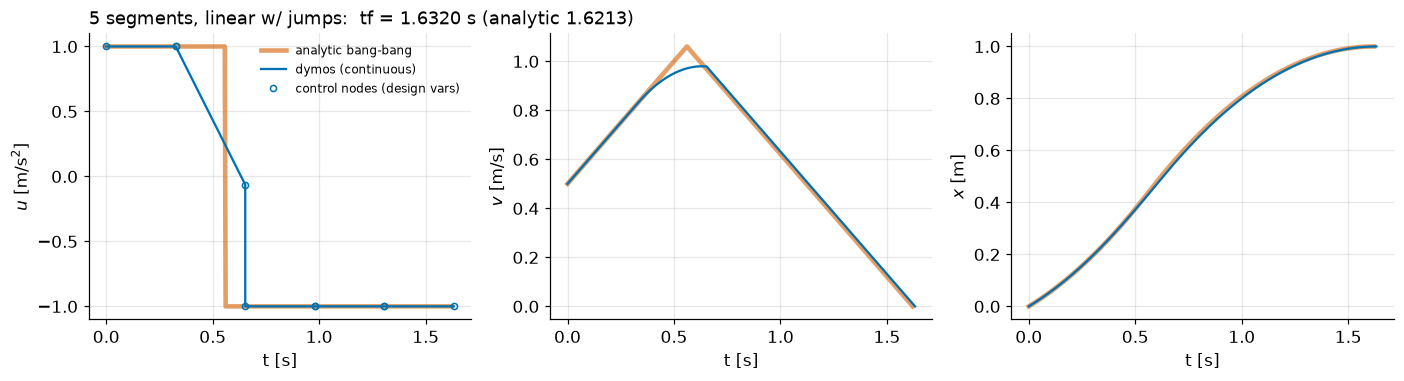

In [14]:
def plot_double_integrator(sol, ana, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, key, ylabel in zip(axes, ('u', 'v', 'x'),
                               (r'$u$ [m/s$^2$]', r'$v$ [m/s]', r'$x$ [m]')):
        ax.plot(ana['t'], ana[key], color=COLORS['analytic'], lw=3, alpha=0.6,
                label='analytic bang-bang')
        ax.plot(sol['dense']['time'], sol['dense'][key], lw=1.5,
                color=COLORS['dymos'], label='dymos (continuous)')
        if key == 'u':  # circles only where they mean something: the control
            ax.plot(sol['time'], sol[key], 'o', ms=4, mfc='none',
                    color=COLORS['dymos'], label='control nodes (design vars)')
        ax.set_xlabel('t [s]'); ax.set_ylabel(ylabel)
    axes[0].legend(fontsize=8)
    axes[0].set_title(f"{title}  tf = {sol['tf']:.4f} s "
                      f"(analytic {ana['tf']:.4f})", loc='left')
    fig.tight_layout()
    return fig


plot_double_integrator(sol, ana_di, title='5 segments, linear w/ jumps:');

The control saturates at $\pm 1$ and the terminal constraints are met — but the
switch at $t_s \approx 0.56$ s falls in the *interior* of a segment. The basis
can jump only at segment *boundaries*, so inside the segment the best it can do
is a full-width ramp from $+1$ to $-1$: the switch gets **smeared across one
segment**, and the rounded corner propagates into $v$. The optimal $t_f$ is
still close because the cost is insensitive to the exact switch shape (a flat
optimum — worth remembering when we study the indirect method in L11).

### It's not the basis order — it's where the boundaries are

We sweep the number of segments (storing each solution; the slider below
scrubs through them without re-solving), solving each case with **two bases**:
our piecewise-linear-with-jumps control, and the smoother
piecewise-quadratic *continuous* control. Watch two things:

1. the error does **not** decrease monotonically with more segments — for
   *either* basis (3 segments beats 4, 5, and 8!), and
2. the quadratic basis is somewhat more accurate — not because the optimum is
   smooth (it is piecewise *constant*), but because with three nodes per
   segment it has more freedom inside the switching segment: it can hug $+1$
   and then dive, placing its sign change *off-center*, nearer the true
   $t_s$, where the linear basis is stuck with one full-width ramp. A constant
   factor, though — it does **not** restore convergence.

Both observations have one explanation: the error is dominated by **the
distance from the nearest segment boundary to the optimal switch time**. A
boundary that happens to sit near $t_s/t_f \approx 34.6\%$ — like the $1/3$
boundary with 3 segments — lets the control change sign almost exactly where
it should, beating five times as many misaligned segments.

In [15]:
sweep_segments = [2, 3, 4, 5, 8, 16]
sweep = {}       # basis 1: piecewise linear, jumps at segment boundaries
sweep_quad = {}  # basis 2: piecewise quadratic, continuous
for ns in sweep_segments:
    sweep[ns] = solve_and_extract(ns, nodes_per_seg=2, continuity=False)
    sweep_quad[ns] = solve_and_extract(ns, nodes_per_seg=3, continuity=True)
    print(f"num_segments={ns:3d}: "
          f"err {abs(sweep[ns]['tf'] - ana_di['tf']):.1e} (linear w/ jumps)   "
          f"{abs(sweep_quad[ns]['tf'] - ana_di['tf']):.1e} (quadratic cont.)   "
          f"success={sweep[ns]['success'] and sweep_quad[ns]['success']}")

num_segments=  2: err 7.3e-02 (linear w/ jumps)   2.8e-02 (quadratic cont.)   success=True
num_segments=  3: err 6.8e-03 (linear w/ jumps)   3.8e-04 (quadratic cont.)   success=True
num_segments=  4: err 1.7e-02 (linear w/ jumps)   1.1e-02 (quadratic cont.)   success=True
num_segments=  5: err 1.1e-02 (linear w/ jumps)   3.0e-03 (quadratic cont.)   success=True
num_segments=  8: err 3.9e-03 (linear w/ jumps)   4.7e-04 (quadratic cont.)   success=True
num_segments= 16: err 9.1e-04 (linear w/ jumps)   8.0e-04 (quadratic cont.)   success=True


In [16]:
import io

# Pre-render every case to an image; the slider just swaps images, so
# scrubbing is instant and no figures are created inside widget callbacks.
def render_png(sol, title):
    with plt.ioff():
        fig = plot_double_integrator(sol, ana_di, title=title)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
        plt.close(fig)
    return buf.getvalue()


sweep_png = {ns: render_png(sweep[ns], f'{ns} segments:')
             for ns in sweep_segments}

seg_slider = widgets.SelectionSlider(options=sweep_segments, value=5,
                                     description='segments',
                                     continuous_update=True)
sweep_img = widgets.Image(value=sweep_png[5], format='png', width=980)
seg_slider.observe(lambda ch: setattr(sweep_img, 'value', sweep_png[ch['new']]),
                   names='value')
display(seg_slider, sweep_img)

SelectionSlider(description='segments', index=3, options=(2, 3, 4, 5, 8, 16), value=5)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05|\x00\x00\x01}\x08\x06\x00\x00\x00\xb7b\xa0\xed\x…

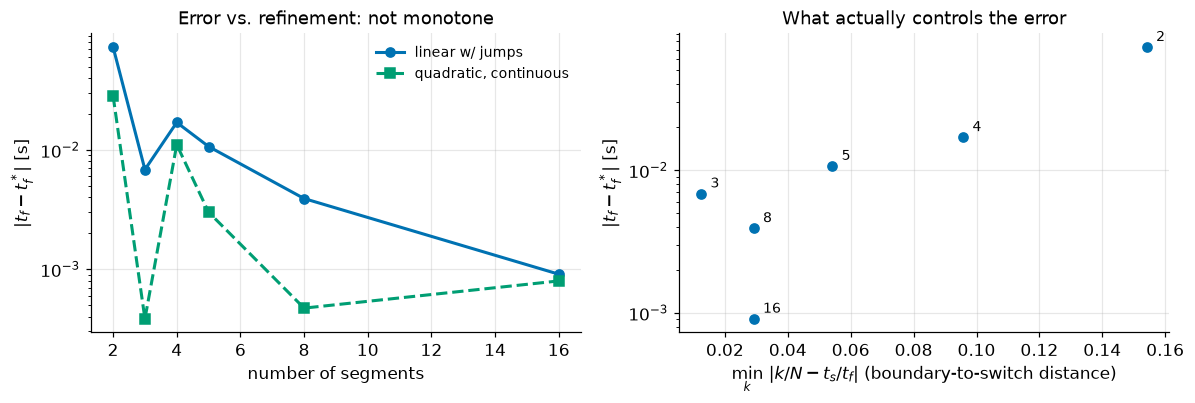

In [17]:
s_star = ana_di['ts'] / ana_di['tf']  # optimal switch as a fraction of the phase
boundary_dist = [min(abs(k / ns - s_star) for k in range(ns + 1))
                 for ns in sweep_segments]
errs_lin = [max(abs(sweep[ns]['tf'] - ana_di['tf']), 1e-16) for ns in sweep_segments]
errs_quad = [max(abs(sweep_quad[ns]['tf'] - ana_di['tf']), 1e-16) for ns in sweep_segments]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.semilogy(sweep_segments, errs_lin, 'o-', color=COLORS['dymos'],
             label='linear w/ jumps')
ax1.semilogy(sweep_segments, errs_quad, 's--', color=COLORS['secondary'],
             label='quadratic, continuous')
ax1.set_xlabel('number of segments'); ax1.set_ylabel(r'$|t_f - t_f^*|$ [s]')
ax1.set_title('Error vs. refinement: not monotone'); ax1.legend(fontsize=9)

ax2.semilogy(boundary_dist, errs_lin, 'o', color=COLORS['dymos'])
for ns, bd, e in zip(sweep_segments, boundary_dist, errs_lin):
    ax2.annotate(f'{ns}', (bd, e), textcoords='offset points',
                 xytext=(6, 4), fontsize=9)
ax2.set_xlabel(r'$\min_k \, | k/N - t_s/t_f |$ (boundary-to-switch distance)')
ax2.set_ylabel(r'$|t_f - t_f^*|$ [s]')
ax2.set_title('What actually controls the error')
fig.tight_layout()

In the right panel every point is one solve from the sweep, labeled by its
segment count $N$. Its horizontal position is how far the *nearest segment
boundary* $k/N$ falls from the optimal switch fraction
$t_s/t_f \approx 0.346$; its height is the resulting final-time error.

Neither panel is monotone on its own, because **two grid properties matter**:

- the **alignment distance** is the primary factor — it explains why 3
  segments beat 4, 5, and 8 in the left panel, and it orders most of the
  right panel;
- the **width of the segment containing the switch** is the secondary one —
  $N = 8$ and $N = 16$ sit at the same alignment distance, and the finer grid
  wins there because the smearing is confined to a narrower segment.

A grid with a boundary sitting *exactly* at $t_s/t_f$ could represent the
bang-bang optimum exactly — but the switch time is *unknown a priori* (it
moves with $v_0$, $d$, and $t_f$ itself), and segment boundaries are fixed
fractions of the duration, not design variables. The principled fix is to
make the boundary location a **variable**: split the trajectory into two
phases — $u=+1$ and $u=-1$ — linked by continuity, with the phase boundary
free. That is exactly the **multi-phase / multiple shooting** formulation of
the next notebook; collocation attacks the same problem with adaptive
**mesh refinement** (L10).

### Live re-solve

Pick a discretization and solve from scratch (takes a few seconds per solve —
this is shooting, after all: every function evaluation is a full adaptive
integration, and every Jacobian a sensitivity propagation).

In [18]:
ns_w = widgets.IntSlider(value=5, min=1, max=33, step=1, description='segments')
nps_w = widgets.IntSlider(value=2, min=2, max=6, description='nodes/seg')
cont_w = widgets.Checkbox(value=False, description='control continuity')
btn = widgets.Button(description='Solve', button_style='primary')
out = widgets.Output()


def on_solve(_):
    with out:
        out.clear_output(wait=True)
        print(f'solving with {ns_w.value} segments, {nps_w.value} nodes/seg ...')
        s = solve_and_extract(ns_w.value, nps_w.value, cont_w.value)
        out.clear_output(wait=True)
        img = widgets.Image(
            value=render_png(s, f'{ns_w.value} seg, order {nps_w.value - 1}:'),
            format='png', width=980)
        display(img)
        print(f"wall time {s['wall']:.1f} s, success={s['success']}")


btn.on_click(on_solve)
display(widgets.HBox([ns_w, nps_w, cont_w, btn]), out)

Output()

---
## 4. Takeaways

1. **Single shooting = a small, tightly coupled NLP.** Design variables are
   only the control parameters and the phase duration; states are eliminated
   by the integrator. Terminal conditions become nonlinear constraints on the
   integrated final state.
2. **Derivatives are the expensive part.** dymos propagates analytic
   sensitivities (the STM) through the adaptive integration — accurate, but
   every Jacobian column costs a propagation, and the rows tied to the
   integrated state are fully coupled: far denser than anything collocation
   (L10) or multiple shooting will hand the optimizer, and they gain no
   structure as the problem grows.
3. **Bang-bang solutions defeat any fixed control grid** — the error is set by
   the distance from the nearest segment boundary to the (a priori unknown)
   switch time, not by segment count or basis order. The fix is to stop fixing
   the grid: the next notebook's two-phase formulation makes the switch time a
   design variable, collocation refines the mesh adaptively (L10), and
   indirect approaches naturally resolve the switch (L11).

**Next notebook:** from single to *multiple* shooting — breaking the
trajectory into independently integrated arcs stitched by continuity defects;
then making the boundary-alignment observation above a design principle with a
two-phase formulation whose phase boundary *is* the switch time; and a
two more complex examples.